In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 


In [3]:
# load dataset
df=pd.read_csv('DataCoSupplyChainDataset.csv',encoding='unicode_escape')
df

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/15/2018 11:24,Standard Class
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,CASH,4,4,40.000000,399.980011,Shipping on time,0,45,Fishing,Brooklyn,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 3:40,Standard Class
180515,DEBIT,3,2,-613.770019,395.980011,Late delivery,1,45,Fishing,Bakersfield,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/19/2016 1:34,Second Class
180516,TRANSFER,5,4,141.110001,391.980011,Late delivery,1,45,Fishing,Bristol,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 21:00,Standard Class
180517,PAYMENT,3,4,186.229996,387.980011,Advance shipping,0,45,Fishing,Caguas,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/18/2016 20:18,Standard Class


In [4]:
#data cleaning
print('rows,columns:',df.shape)
print('\n Columns:')
print(df.columns.to_list())
print('\n Num duplicates:',df.duplicated().sum())
print('\n Missing values(top 20):')
print(df.isnull().sum().sort_values(ascending=False).head(20))

rows,columns: (180519, 53)

 Columns:
['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', 'Product Price', 'Pro

In [5]:
# remove columns that are not relavent to the analysis 
columns_to_drop=[ 'Customer Lname','Customer Email',  
                  'Customer Password',
                  'Customer Segment',
                  'Customer Zipcode', 
                  'Latitude', 
                  'Longitude',
                  'Market', 
                  'Order Zipcode',
                  'Product Card Id', 
                  'Product Category Id',
                  'Product Description', 
                  'Product Image'
                 
                 ]

In [6]:
#drop the columns from the data 
df=df.drop(columns=columns_to_drop)

In [7]:
df

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,314.640015,91.250000,Southeast Asia,Java Occidental,COMPLETE,Smart watch,327.750000,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,311.359985,-249.089996,South Asia,Rajastán,PENDING,Smart watch,327.750000,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,309.720001,-247.779999,South Asia,Rajastán,CLOSED,Smart watch,327.750000,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,304.809998,22.860001,Oceania,Queensland,COMPLETE,Smart watch,327.750000,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,298.250000,134.210007,Oceania,Queensland,PENDING_PAYMENT,Smart watch,327.750000,0,1/15/2018 11:24,Standard Class
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,CASH,4,4,40.000000,399.980011,Shipping on time,0,45,Fishing,Brooklyn,...,399.980011,40.000000,Eastern Asia,Shanghái,CLOSED,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 3:40,Standard Class
180515,DEBIT,3,2,-613.770019,395.980011,Late delivery,1,45,Fishing,Bakersfield,...,395.980011,-613.770019,Eastern Asia,Osaka,COMPLETE,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/19/2016 1:34,Second Class
180516,TRANSFER,5,4,141.110001,391.980011,Late delivery,1,45,Fishing,Bristol,...,391.980011,141.110001,Oceania,Australia del Sur,PENDING,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 21:00,Standard Class
180517,PAYMENT,3,4,186.229996,387.980011,Advance shipping,0,45,Fishing,Caguas,...,387.980011,186.229996,Oceania,Australia del Sur,PENDING_PAYMENT,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/18/2016 20:18,Standard Class


In [8]:
#removing the order details that cancelled
df=df[(df['Delivery Status']!='Shipping canceled')]
df

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,314.640015,91.250000,Southeast Asia,Java Occidental,COMPLETE,Smart watch,327.750000,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,311.359985,-249.089996,South Asia,Rajastán,PENDING,Smart watch,327.750000,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,309.720001,-247.779999,South Asia,Rajastán,CLOSED,Smart watch,327.750000,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,304.809998,22.860001,Oceania,Queensland,COMPLETE,Smart watch,327.750000,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,298.250000,134.210007,Oceania,Queensland,PENDING_PAYMENT,Smart watch,327.750000,0,1/15/2018 11:24,Standard Class
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,CASH,4,4,40.000000,399.980011,Shipping on time,0,45,Fishing,Brooklyn,...,399.980011,40.000000,Eastern Asia,Shanghái,CLOSED,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 3:40,Standard Class
180515,DEBIT,3,2,-613.770019,395.980011,Late delivery,1,45,Fishing,Bakersfield,...,395.980011,-613.770019,Eastern Asia,Osaka,COMPLETE,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/19/2016 1:34,Second Class
180516,TRANSFER,5,4,141.110001,391.980011,Late delivery,1,45,Fishing,Bristol,...,391.980011,141.110001,Oceania,Australia del Sur,PENDING,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 21:00,Standard Class
180517,PAYMENT,3,4,186.229996,387.980011,Advance shipping,0,45,Fishing,Caguas,...,387.980011,186.229996,Oceania,Australia del Sur,PENDING_PAYMENT,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/18/2016 20:18,Standard Class


In [9]:
#standard data conversion
for c in ['order date (DateOrders)','shipping date (DateOrders)']:
    df[c]=pd.to_datetime(df[c],dayfirst=False)
print(df[c])



0        2018-02-03 22:56:00
1        2018-01-18 12:27:00
2        2018-01-17 12:06:00
3        2018-01-16 11:45:00
4        2018-01-15 11:24:00
                 ...        
180514   2016-01-20 03:40:00
180515   2016-01-19 01:34:00
180516   2016-01-20 21:00:00
180517   2016-01-18 20:18:00
180518   2016-01-19 18:54:00
Name: shipping date (DateOrders), Length: 172765, dtype: datetime64[us]


In [10]:
# after cleaning columns 
print('rows,columns:',df.shape)
print('\n Columns:')
print(df.columns.to_list())
print('\n Num duplicates:',df.duplicated().sum())
print('\n Missing values(top 20):')
print(df.isnull().sum().sort_values(ascending=False).head(20))

rows,columns: (172765, 40)

 Columns:
['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Fname', 'Customer Id', 'Customer State', 'Customer Street', 'Department Id', 'Department Name', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Product Name', 'Product Price', 'Product Status', 'shipping date (DateOrders)', 'Shipping Mode']

 Num duplicates: 0

 Missing values(top 20):
Type                             0
Days for shipping (real)         0
Days for shipment (scheduled)    0
Benefit per order  

In [11]:
df=df.drop(columns='Customer Lname')
df

KeyError: "['Customer Lname'] not found in axis"

In [12]:
#vaues count for catergorical columns with low cardinarlity 
for col in df.columns:
    if df[col].nunique()<10:
        print(f'\n{col} value counts:')
        print(df[col].value_counts())


Type value counts:
Type
DEBIT       69295
TRANSFER    42129
PAYMENT     41725
CASH        19616
Name: count, dtype: int64

Days for shipping (real) value counts:
Days for shipping (real)
2    54205
6    27489
3    27478
4    27297
5    27003
0     4839
1     4454
Name: count, dtype: int64

Days for shipment (scheduled) value counts:
Days for shipment (scheduled)
4    103153
2     33806
1     26513
0      9293
Name: count, dtype: int64

Delivery Status value counts:
Delivery Status
Late delivery       98977
Advance shipping    41592
Shipping on time    32196
Name: count, dtype: int64

Late_delivery_risk value counts:
Late_delivery_risk
1    98977
0    73788
Name: count, dtype: int64

Customer Country value counts:
Customer Country
EE. UU.        106425
Puerto Rico     66340
Name: count, dtype: int64

Order Item Quantity value counts:
Order Item Quantity
1    94904
5    19510
4    19481
3    19473
2    19397
Name: count, dtype: int64

Order Status value counts:
Order Status
COMPLETE    

In [13]:
#calculating order precessing time and delivery 
df['Order Processing Time']=(df['shipping date (DateOrders)']-df['order date (DateOrders)']).dt.days
df['Delay']=df['Order Processing Time']-df['Days for shipment (scheduled)']
df['IsDelayed']=df['Delay']>0
df['Order Month']=df['order date (DateOrders)'].dt.month
df['Order Day']=df['order date (DateOrders)'].dt.day_name()
df['Order_hour']=df['order date (DateOrders)'].dt.hour
df.describe()



,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Customer Id,Department Id,Order Customer Id,order date (DateOrders),...,Sales,Order Item Total,Order Profit Per Order,Product Price,Product Status,shipping date (DateOrders),Order Processing Time,Delay,Order Month,Order_hour
count,172765.000000,172765.000000,172765.000000,172765.000000,172765.000000,172765.000000,172765.000000,172765.000000,172765.000000,172765,...,172765.000000,172765.000000,172765.000000,172765.000000,172765.0,172765,172765.000000,172765.000000,172765.000000,172765.000000
mean,3.498596,2.933100,22.032360,183.165948,0.572900,31.856065,6687.759048,5.444095,6687.759048,2016-06-12 15:25:39.457991,...,203.828493,183.165948,22.032360,141.278595,0.0,2016-06-16 03:25:14.452927,3.472816,0.539716,6.235511,11.482604
min,0.000000,0.000000,-4274.979980,7.490000,0.000000,2.000000,1.000000,2.000000,1.000000,2015-01-01 00:00:00,...,9.990000,7.490000,-4274.979980,9.990000,0.0,2015-01-03 00:00:00,0.000000,-2.000000,1.000000,0.000000
25%,2.000000,2.000000,7.030000,104.379997,0.000000,18.000000,3252.000000,4.000000,3252.000000,2015-09-21 18:01:00,...,119.980003,104.379997,7.030000,50.000000,0.0,2015-09-25 08:59:00,2.000000,0.000000,3.000000,5.000000
50%,3.000000,4.000000,31.520000,163.990005,1.000000,29.000000,6457.000000,5.000000,6457.000000,2016-06-11 08:11:00,...,199.919998,163.990005,31.520000,59.990002,0.0,2016-06-15 03:38:00,3.000000,1.000000,6.000000,11.000000
75%,5.000000,4.000000,64.800003,247.399994,1.000000,45.000000,9782.000000,7.000000,9782.000000,2017-02-28 21:08:00,...,299.950012,247.399994,64.800003,199.990005,0.0,2017-03-04 08:00:00,5.000000,1.000000,9.000000,17.000000
max,6.000000,4.000000,911.799988,1939.989990,1.000000,76.000000,20757.000000,12.000000,20757.000000,2018-01-31 23:38:00,...,1999.989990,1939.989990,911.799988,1999.989990,0.0,2018-02-06 22:14:00,6.000000,4.000000,12.000000,23.000000
std,1.623446,1.373405,104.355313,120.141871,0.494659,15.642216,4165.069180,1.629248,4165.069180,NaN,...,132.392520,120.141871,104.355313,139.862956,0.0,NaN,1.670187,1.494150,3.405593,6.927276


In [14]:
#count of the delay
df['IsDelayed'].value_counts()


IsDelayed
True     94523
False    78242
Name: count, dtype: int64

In [15]:
#based on the delivery time got profit or loss Analysis
df['Order Item Profit Ratio']


0         0.29
1        -0.80
2        -0.80
3         0.08
4         0.45
          ... 
180514    0.10
180515   -1.55
180516    0.36
180517    0.48
180518    0.44
Name: Order Item Profit Ratio, Length: 172765, dtype: float64

In [16]:
#create a categorical like profit,loss and break event (no loss/gain)
df['Profitability Flag']=np.where(df['Order Item Profit Ratio']>0,'Profit',
                                  np.where(df['Order Item Profit Ratio']<0,'Loss','Break-Event'))
df['Profitability Flag'].value_counts()

Profitability Flag
Profit         139354
Loss            32295
Break-Event      1116
Name: count, dtype: int64

In [17]:
#percentage wise check the profit,loss,Break-Event
df['Profitability Flag'].value_counts(normalize=True)

Profitability Flag
Profit         0.80661
Loss           0.18693
Break-Event    0.00646
Name: proportion, dtype: float64

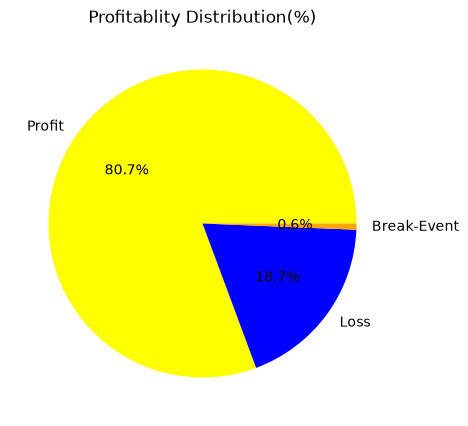

In [18]:
#visualization
#pie chart 
fig,ax=plt.subplots(nrows=1,ncols=1,figsize=(12,5))
profit_counts=df['Profitability Flag'].value_counts(normalize=True)*100
profit_counts.plot(kind='pie',autopct='%1.1f%%',colors=['yellow','blue','orange'])
plt.ylabel('')
plt.title('Profitablity Distribution(%)')
plt.savefig('Categorical like profit,loss,break-event.jpg')
plt.show()

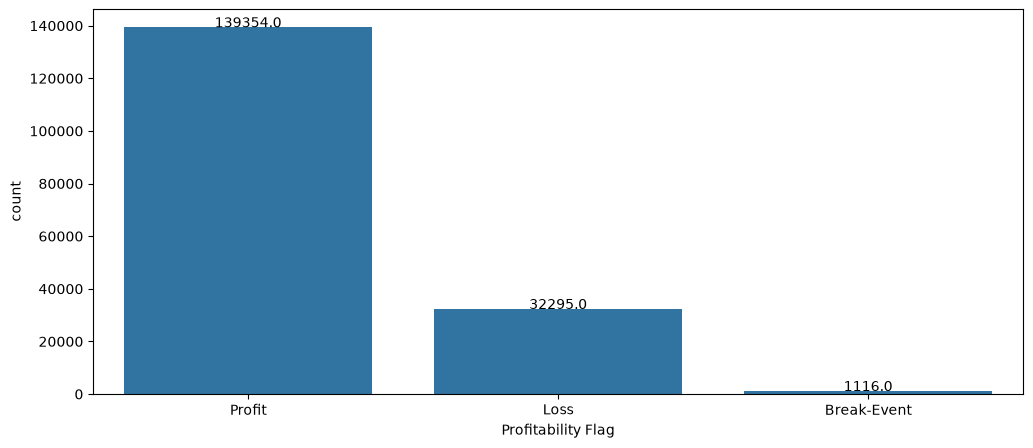

In [19]:
#bar chart
fig,ax=plt.subplots(nrows=1,ncols=1,figsize=(12,5))
sns.countplot(x='Profitability Flag',data=df)
for bar in ax.patches:
    yval=bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2.0,yval+40,yval,ha='center')


In [20]:
#Total profit generated by all profitable orders
total_profit = df.loc[df['Profitability Flag'] == 'Profit', 'Benefit per order'].sum()
print(f"Total Profit (profitable orders): ${total_profit:,.0f}")
 

Total Profit (profitable orders): $7,514,814


In [21]:
# Profit at risk = profit tied up in orders that were ALSO delayed
profit_at_risk = df.loc[(df['IsDelayed'] == True) & (df['Profitability Flag'] == 'Profit'),
                         'Benefit per order'].sum()
print(f"Profit at Risk (delayed orders): ${profit_at_risk:,.0f}")
 

Profit at Risk (delayed orders): $4,111,375


In [22]:
# 90th percentile of delay — "how bad do the worst-but-common delays get?"
delay_90th = df['Delay'].quantile(0.90)
print(f"90th Percentile Delay: {delay_90th:.0f} days")

90th Percentile Delay: 2 days


In [23]:
# Average order profit 
avg_order_profit = df['Benefit per order'].mean()
print(f"Avg Order Profit: ${avg_order_profit:.2f}")

Avg Order Profit: $22.03


In [24]:
# Delay rate by region
delay_by_region = df.groupby('Order Region')['IsDelayed'].mean().sort_values(ascending=False) * 100
print("\nDelay % by Region:\n", delay_by_region)
 


Delay % by Region:
 Order Region
Central Africa     58.663366
Southeast Asia     55.965412
Eastern Europe     55.957728
South of  USA      55.927367
East Africa        55.867490
South Asia         55.828303
Western Europe     55.793095
West Asia          55.586495
US Center          55.315762
East of USA        55.145836
Central America    54.710385
South America      54.378173
West of USA        54.088216
Northern Europe    54.060374
Central Asia       54.059041
Eastern Asia       53.950954
Oceania            53.621699
North Africa       53.596889
Southern Europe    53.444075
Caribbean          52.710351
West Africa        52.478297
Southern Africa    52.272727
Canada             50.826902
Name: IsDelayed, dtype: float64


In [25]:
# Delay rate by shipping mode
delay_by_mode = df.groupby('Shipping Mode')['IsDelayed'].mean().sort_values(ascending=False) * 100
print("\nDelay % by Shipping Mode:\n", delay_by_mode)


Delay % by Shipping Mode:
 Shipping Mode
First Class       100.000000
Second Class       79.829024
Standard Class     39.769081
Same Day            0.000000
Name: IsDelayed, dtype: float64


In [26]:
# Delay rate by product category (top 10 worst)
delay_by_category = (df.groupby('Category Name')['IsDelayed'].mean()
                        .sort_values(ascending=False).head(10) * 100)
print("\nTop 10 Categories by Delay %:\n", delay_by_category)


Top 10 Categories by Delay %:
 Category Name
Golf Bags & Carts    67.213115
Lacrosse             59.878419
Cameras              59.786477
Crafts               58.078603
Basketball           57.812500
As Seen on  TV!      57.575758
Accessories          57.336476
Tennis & Racquet     57.006369
Health and Beauty    56.936416
Strength Training    56.880734
Name: IsDelayed, dtype: float64


In [27]:
# Delay rate by order month (seasonality check)
delay_by_month = df.groupby('Order Month')['IsDelayed'].mean().sort_values(ascending=False) * 100
print("\nDelay % by Order Month:\n", delay_by_month)


Delay % by Order Month:
 Order Month
9     55.388454
8     55.387128
12    55.224003
5     54.998022
11    54.860878
3     54.809390
6     54.764535
2     54.604550
4     54.504230
1     54.254150
10    54.097044
7     53.731048
Name: IsDelayed, dtype: float64


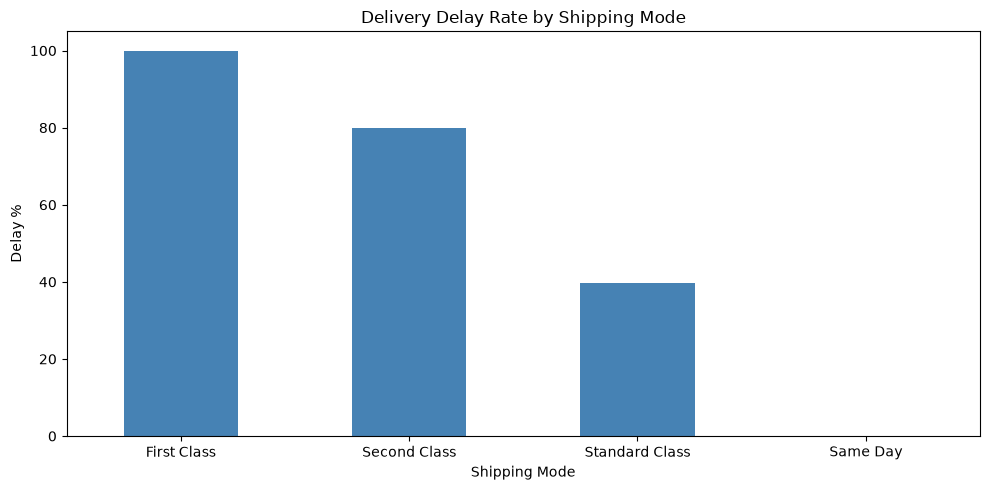

In [28]:
# Visualize delay rate by shipping mode (most actionable dimension for ops teams)
plt.figure(figsize=(10, 5))
delay_by_mode.plot(kind='bar', color='steelblue')
plt.ylabel('Delay %')
plt.title('Delivery Delay Rate by Shipping Mode')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('delay_by_shipping_mode.jpg')
plt.show()

In [29]:
# Compare average scheduled shipping days vs delay rate
# (do tighter schedules cause more delays?)
bottleneck_schedule = df.groupby('Days for shipment (scheduled)')['IsDelayed'].mean() * 100
print("\nDelay % by Scheduled Shipping Days (tighter windows = more delay?):\n", bottleneck_schedule)
 



Delay % by Scheduled Shipping Days (tighter windows = more delay?):
 Days for shipment (scheduled)
0      0.000000
1    100.000000
2     79.829024
4     39.769081
Name: IsDelayed, dtype: float64


In [30]:
# Rank all dimensions by how much their delay rate varies
# (a bigger spread = a bigger operational lever)
bottleneck_summary = pd.DataFrame({
    'Region_spread': [delay_by_region.max() - delay_by_region.min()],
    'ShippingMode_spread': [delay_by_mode.max() - delay_by_mode.min()],
    'Category_spread': [delay_by_category.max() - delay_by_category.min()],
    'Month_spread': [delay_by_month.max() - delay_by_month.min()],
})
print("\nWhich dimension explains the most variation in delay rate:\n", bottleneck_summary.T)
 


Which dimension explains the most variation in delay rate:
                               0
Region_spread          7.836464
ShippingMode_spread  100.000000
Category_spread       10.332381
Month_spread           1.657406


In [34]:
worst_region = delay_by_region.idxmax()
worst_mode = delay_by_mode.idxmax()

recommendations = f"""
KEY RECOMMENDATIONS
--------------------
1. {worst_mode} shipping shows the highest delay rate ({delay_by_mode.max():.1f}%) —
   investigate carrier SLAs or reallocate volume to a more reliable mode.
2. {worst_region} region has the highest delay rate ({delay_by_region.max():.1f}%) —
   review regional fulfillment centers or last-mile logistics partners there.
4. ${profit_at_risk:,.0f} in profit currently sits in delayed orders —
   even a 10% reduction in delay rate could protect a meaningful share of this.
"""
print(recommendations)


KEY RECOMMENDATIONS
--------------------
1. First Class shipping shows the highest delay rate (100.0%) —
   investigate carrier SLAs or reallocate volume to a more reliable mode.
2. Central Africa region has the highest delay rate (58.7%) —
   review regional fulfillment centers or last-mile logistics partners there.
4. $4,111,375 in profit currently sits in delayed orders —
   even a 10% reduction in delay rate could protect a meaningful share of this.

